# Fit Dunst + Freund Models To Measured Lactate

This notebook fits, for each participant:
1. The Dunst-style exercise model (exercise phase).
2. The Freund/Durand recovery model (recovery phase).

The fitting is done directly on measured lactate values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# File and timing configuration
XLS_FILE = "../DATA/Physio_Session2_Wingate.xlsx"
SHEET_NAME = "data"

START_TIME_S = 15
WINGATE_DURATION_S = 30
END_TIME_S = START_TIME_S + WINGATE_DURATION_S

# Dunst model constants
EXERCISE_DELAY_S = 2.0
EXERCISE_K3 = 0.18
EXERCISE_K4 = 0.06

# Default Freund parameters (used only as fallback)
DELTA_PEAK_DEFAULT = 10.0
GAMMA1_DEFAULT = 1 / 300
GAMMA2_DEFAULT = 1 / 2000

In [7]:
def to_abs_time_s(time_min):
    if time_min == -1:
        return START_TIME_S - 60
    return END_TIME_S + float(time_min) * 60.0


def dunst_delta(t_after_start_s, delta_end_target, delay_s=EXERCISE_DELAY_S, k3=EXERCISE_K3, k4=EXERCISE_K4):
    t_after_start_s = np.asarray(t_after_start_s, dtype=float)
    t_eff = np.clip(t_after_start_s - delay_s, 0.0, max(WINGATE_DURATION_S - delay_s, 0.0))

    g0 = -(1.0 / k3) + (1.0 / k4)
    g_end = (
        -(1.0 / k3) * np.exp(-k3 * max(WINGATE_DURATION_S - delay_s, 0.0))
        + (1.0 / k4) * np.exp(-k4 * max(WINGATE_DURATION_S - delay_s, 0.0))
    )
    denom = g_end - g0

    if np.isclose(denom, 0.0):
        return np.full_like(t_eff, float(delta_end_target), dtype=float)

    b_coef = float(delta_end_target) / denom
    c_coef = -b_coef * g0
    delta = b_coef * (
        -(1.0 / k3) * np.exp(-k3 * t_eff)
        + (1.0 / k4) * np.exp(-k4 * t_eff)
    ) + c_coef

    return np.maximum(delta, 0.0)


def dunst_lactate_abs(abs_t_s, la_base, delta_end_target):
    abs_t_s = np.asarray(abs_t_s, dtype=float)
    out = np.full_like(abs_t_s, float(la_base), dtype=float)

    exercise_mask = (abs_t_s >= START_TIME_S) & (abs_t_s <= END_TIME_S)
    if np.any(exercise_mask):
        t_after_start = abs_t_s[exercise_mask] - START_TIME_S
        out[exercise_mask] = float(la_base) + dunst_delta(t_after_start, delta_end_target)

    return out


def freund_recovery(t_after_rec_s, la_base, la_rec, delta_peak, gamma1, gamma2):
    t_after_rec_s = np.maximum(np.asarray(t_after_rec_s, dtype=float), 0.0)
    return (
        la_rec
        + (delta_peak + la_base - la_rec) * (1 - np.exp(-gamma1 * t_after_rec_s))
        + (-delta_peak) * (1 - np.exp(-gamma2 * t_after_rec_s))
    )


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(y_pred - y_true))


def r2_score_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return float(1 - ss_res / ss_tot)

In [3]:
lac_all = pd.read_excel(XLS_FILE, sheet_name=SHEET_NAME)
lac_all.columns = [str(c).strip() for c in lac_all.columns]
lac_all["Time"] = pd.to_numeric(lac_all["Time"], errors="coerce")
lac_all["[La]"] = pd.to_numeric(lac_all["[La]"], errors="coerce")
lac_all = lac_all.dropna(subset=["Name", "Time", "[La]"]).copy()

participants = sorted(lac_all["Name"].astype(str).str.strip().unique().tolist())
print("Participants found:", participants)

Participants found: ['Alexis', 'Antoine', 'Enzo', 'Jinwei', 'Victor']


In [8]:
fit_rows = []
fit_curves = {}
fit_points = {}

for participant in participants:
    sub = lac_all[lac_all["Name"].astype(str).str.strip().str.lower() == participant.lower()].copy()
    sub = sub.sort_values("Time")

    base_row = sub[sub["Time"] == -1]
    rec0_row = sub[sub["Time"] == 0]

    if base_row.empty or rec0_row.empty:
        print(f"Skipping {participant}: missing baseline (-1) or handoff (0).")
        continue

    la_base = float(base_row["[La]"].iloc[0])
    la_rec = float(rec0_row["[La]"].iloc[0])

    # Exercise-phase fit with available exercise anchors (baseline and handoff).
    delta_end_fit = max(la_rec - la_base, 0.0)

    exercise_abs_t = np.array([START_TIME_S - 60, END_TIME_S], dtype=float)
    exercise_y_true = np.array([la_base, la_rec], dtype=float)
    exercise_y_pred = np.array([la_base, la_base + delta_end_fit], dtype=float)
    rmse_exercise = rmse(exercise_y_true, exercise_y_pred)

    # Recovery-phase fit on measured points after recovery onset (Time > 0).
    rec = sub[sub["Time"] > 0].copy()

    if len(rec) >= 3:
        t_rec_s = rec["Time"].to_numpy(float) * 60.0
        y_rec = rec["[La]"].to_numpy(float)

        delta_peak_init = max(float(np.max(y_rec) - la_base), 0.1)

        def recovery_for_fit(t, delta_peak, gamma1, gamma2):
            return freund_recovery(t, la_base, la_rec, delta_peak, gamma1, gamma2)

        try:
            p0 = [delta_peak_init, GAMMA1_DEFAULT, GAMMA2_DEFAULT]
            bounds = ([0.0, 1 / 10000, 1 / 10000], [40.0, 1 / 20, 1 / 20])
            popt, _ = curve_fit(recovery_for_fit, t_rec_s, y_rec, p0=p0, bounds=bounds, maxfev=50000)
            delta_peak_fit = float(popt[0])
            gamma1_fit = float(popt[1])
            gamma2_fit = float(popt[2])
        except Exception:
            delta_peak_fit = float(delta_peak_init)
            gamma1_fit = float(GAMMA1_DEFAULT)
            gamma2_fit = float(GAMMA2_DEFAULT)

        y_rec_pred = freund_recovery(t_rec_s, la_base, la_rec, delta_peak_fit, gamma1_fit, gamma2_fit)
        rmse_recovery = rmse(y_rec, y_rec_pred)
    else:
        delta_peak_fit = np.nan
        gamma1_fit = np.nan
        gamma2_fit = np.nan
        rmse_recovery = np.nan

    # Build fitted values at measured sampling times (full phase-aware model).
    measured_eval = sub[["Time", "[La]"]].copy()
    measured_eval["t_abs_s"] = measured_eval["Time"].apply(to_abs_time_s)

    y_fit_at_samples = []
    for _, rr in measured_eval.iterrows():
        t_abs = float(rr["t_abs_s"])

        if t_abs < START_TIME_S:
            y_hat = la_base
        elif t_abs <= END_TIME_S:
            y_hat = float(dunst_lactate_abs(np.array([t_abs]), la_base, delta_end_fit)[0])
        else:
            t_after_rec = t_abs - END_TIME_S
            if np.isfinite(delta_peak_fit) and np.isfinite(gamma1_fit) and np.isfinite(gamma2_fit):
                y_hat = float(freund_recovery(np.array([t_after_rec]), la_base, la_rec, delta_peak_fit, gamma1_fit, gamma2_fit)[0])
            else:
                y_hat = np.nan

        y_fit_at_samples.append(y_hat)

    measured_eval["La_fit"] = y_fit_at_samples

    valid_eval = measured_eval.dropna(subset=["La_fit"]).copy()
    rmse_all = rmse(valid_eval["[La]"], valid_eval["La_fit"]) if len(valid_eval) > 0 else np.nan
    mae_all = mae(valid_eval["[La]"], valid_eval["La_fit"]) if len(valid_eval) > 0 else np.nan
    bias_all = bias(valid_eval["[La]"], valid_eval["La_fit"]) if len(valid_eval) > 0 else np.nan
    r2_all = r2_score_safe(valid_eval["[La]"], valid_eval["La_fit"]) if len(valid_eval) > 0 else np.nan

    # Continuous fitted curve for plotting.
    max_time_min = float(np.nanmax(sub["Time"])) if len(sub) > 0 else 12.0
    t_cont = np.arange(START_TIME_S - 60, END_TIME_S + max_time_min * 60.0 + 1, 1.0)

    la_cont = np.full_like(t_cont, la_base, dtype=float)

    mask_ex = (t_cont >= START_TIME_S) & (t_cont <= END_TIME_S)
    if np.any(mask_ex):
        la_cont[mask_ex] = dunst_lactate_abs(t_cont[mask_ex], la_base, delta_end_fit)

    mask_rec = t_cont > END_TIME_S
    if np.any(mask_rec) and np.isfinite(delta_peak_fit) and np.isfinite(gamma1_fit) and np.isfinite(gamma2_fit):
        la_cont[mask_rec] = freund_recovery(
            t_cont[mask_rec] - END_TIME_S,
            la_base,
            la_rec,
            delta_peak_fit,
            gamma1_fit,
            gamma2_fit,
        )

    fit_curves[participant] = pd.DataFrame({"Time_abs_s": t_cont, "La_fit": la_cont})
    fit_points[participant] = measured_eval.copy()

    fit_rows.append({
        "Participant": participant,
        "La_base": la_base,
        "La_recovery_onset": la_rec,
        "delta_end_exercise_fit": delta_end_fit,
        "k3_exercise": EXERCISE_K3,
        "k4_exercise": EXERCISE_K4,
        "delta_peak_recovery_fit": delta_peak_fit,
        "gamma1_recovery_fit": gamma1_fit,
        "gamma2_recovery_fit": gamma2_fit,
        "RMSE_exercise_anchor": rmse_exercise,
        "RMSE_recovery": rmse_recovery,
        "RMSE_all_points": rmse_all,
        "MAE_all_points": mae_all,
        "Bias_all_points": bias_all,
        "R2_all_points": r2_all,
    })

fit_df = pd.DataFrame(fit_rows)
fit_df

,Participant,La_base,La_recovery_onset,delta_end_exercise_fit,k3_exercise,k4_exercise,delta_peak_recovery_fit,gamma1_recovery_fit,gamma2_recovery_fit,RMSE_exercise_anchor,RMSE_recovery,RMSE_all_points,MAE_all_points,Bias_all_points,R2_all_points
0,Alexis,1.70,6.9,5.20,0.18,0.06,13.297034,0.035689,0.000292,0.0,0.881299,0.797165,0.553645,-0.000553,0.955942
1,Antoine,2.20,11.5,9.30,0.18,0.06,14.525327,0.014237,0.000350,0.0,1.013390,0.916646,0.675703,0.000226,0.940232
2,Enzo,2.60,15.6,13.00,0.18,0.06,19.388527,0.050000,0.001238,0.0,1.547936,1.263884,1.027077,-0.020199,0.934251
3,Jinwei,2.50,17.0,14.50,0.18,0.06,10.460691,0.050000,0.000188,0.0,1.133752,1.025517,0.732300,0.000194,0.908939
4,Victor,0.75,6.9,6.15,0.18,0.06,11.916079,0.013389,0.000100,0.0,0.824057,0.745387,0.598864,-0.003355,0.954649


In [5]:
print("===== FITTED PARAMETERS (PER PARTICIPANT) =====")
display_cols = [
    "Participant",
    "La_base",
    "La_recovery_onset",
    "delta_end_exercise_fit",
    "delta_peak_recovery_fit",
    "gamma1_recovery_fit",
    "gamma2_recovery_fit",
    "RMSE_recovery",
    "RMSE_all_points",
    "MAE_all_points",
]
print(fit_df[display_cols])

if len(fit_df) > 0:
    pooled_rmse = float(np.sqrt(np.nanmean(fit_df["RMSE_all_points"] ** 2)))
    pooled_mae = float(np.nanmean(fit_df["MAE_all_points"]))
    print("\n===== OVERALL =====")
    print(f"Pooled RMSE across participants = {pooled_rmse:.3f} mmol/L")
    print(f"Mean MAE across participants   = {pooled_mae:.3f} mmol/L")

===== FITTED PARAMETERS (PER PARTICIPANT) =====
  Participant  La_base  La_recovery_onset  delta_end_exercise_fit  \
0      Alexis     1.70                6.9                    5.20   
1     Antoine     2.20               11.5                    9.30   
2        Enzo     2.60               15.6                   13.00   
3      Jinwei     2.50               17.0                   14.50   
4      Victor     0.75                6.9                    6.15   

   delta_peak_recovery_fit  gamma1_recovery_fit  gamma2_recovery_fit  \
0                13.297034             0.035689             0.000292   
1                14.525327             0.014237             0.000350   
2                19.388527             0.050000             0.001238   
3                10.460691             0.050000             0.000188   
4                11.916079             0.013389             0.000100   

   RMSE_recovery  RMSE_all_points  MAE_all_points  
0       0.881299         0.797165        0.553645  


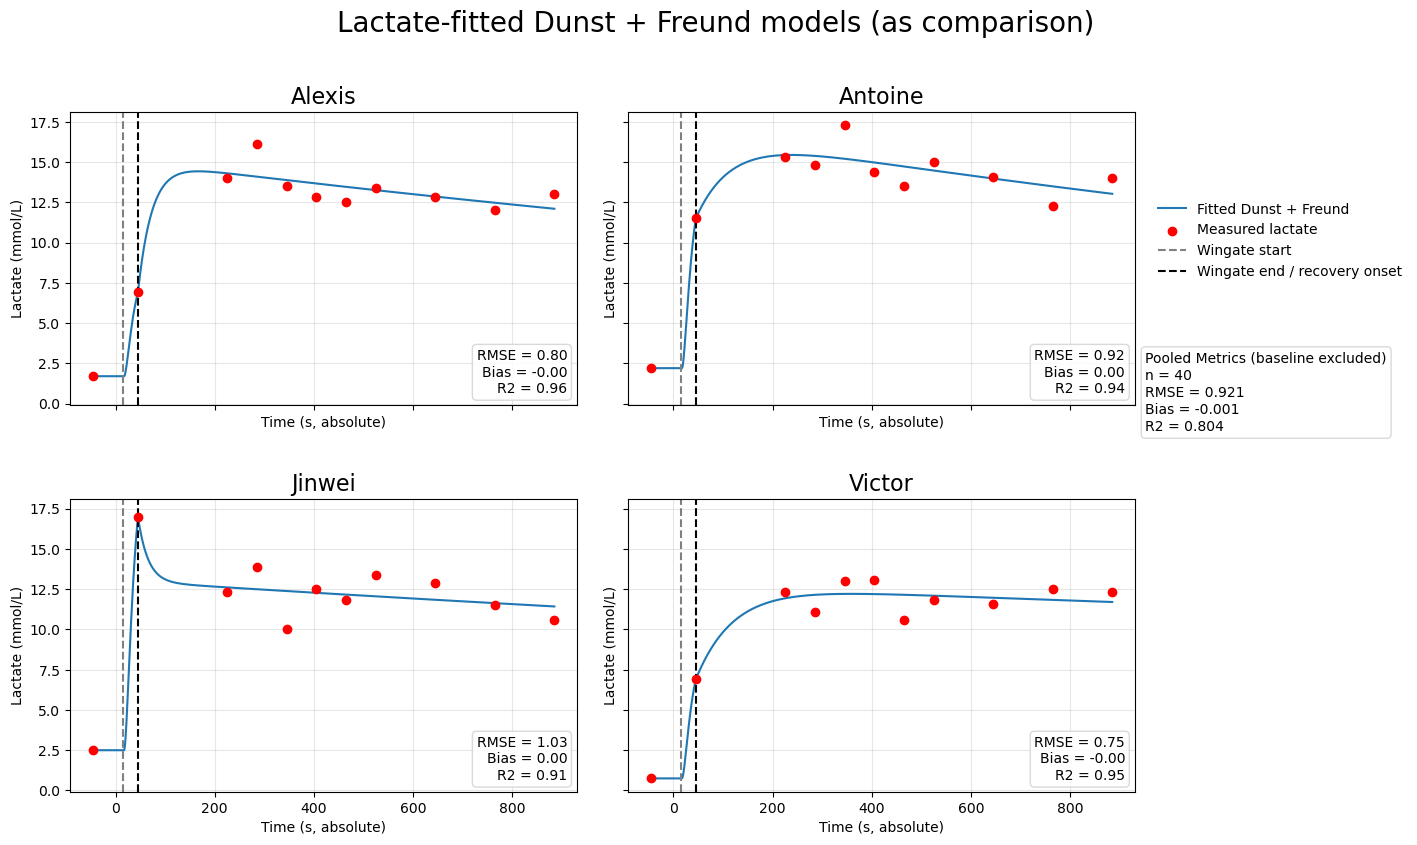

In [27]:
plot_participants = [p for p in fit_df["Participant"].tolist() if str(p).strip().lower() != "enzo"][:4]

if len(plot_participants) == 0:
    print("No participants to plot after excluding Enzo.")
else:
    pooled_parts = []
    for participant in plot_participants:
        pooled_pts = fit_points[participant].copy()
        pooled_pts = pooled_pts.dropna(subset=["La_fit"]).copy()
        pooled_pts = pooled_pts[pooled_pts["Time"] != -1].copy()
        if len(pooled_pts) > 0:
            pooled_parts.append(pooled_pts)

    pooled_rmse = np.nan
    pooled_bias = np.nan
    pooled_r2 = np.nan
    pooled_n = 0
    if len(pooled_parts) > 0:
        pooled_eval = pd.concat(pooled_parts, ignore_index=True)
        pooled_n = int(len(pooled_eval))
        pooled_rmse = rmse(pooled_eval["[La]"], pooled_eval["La_fit"])
        pooled_bias = bias(pooled_eval["[La]"], pooled_eval["La_fit"])
        pooled_r2 = r2_score_safe(pooled_eval["[La]"], pooled_eval["La_fit"])

    fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, participant in zip(axes, plot_participants):
        curve = fit_curves[participant]
        pts = fit_points[participant]

        ax.plot(curve["Time_abs_s"], curve["La_fit"], label="Fitted Dunst + Freund", color="tab:blue")
        ax.scatter(pts["t_abs_s"], pts["[La]"], color="red", label="Measured lactate", zorder=3)

        ax.axvline(START_TIME_S, linestyle="--", color="gray", label="Wingate start")
        ax.axvline(END_TIME_S, linestyle="--", color="black", label="Wingate end / recovery onset")

        row = fit_df[fit_df["Participant"] == participant].iloc[0]
        r2_panel = row["R2_all_points"]
        r2_str = f"{r2_panel:.2f}" if np.isfinite(r2_panel) else "nan"
        metrics_text = (
            f"RMSE = {row['RMSE_all_points']:.2f}\n"
            f"Bias = {row['Bias_all_points']:.2f}\n"
            f"R2 = {r2_str}"
        )

        ax.set_title(f"{participant}", fontsize=16)
        ax.text(
            0.98,
            0.03,
            metrics_text,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=10,
            linespacing=1.25,
            bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
        )

        ax.set_xlabel("Time (s, absolute)")
        ax.set_ylabel("Lactate (mmol/L)")
        ax.grid(True, alpha=0.3)

    for i in range(len(plot_participants), len(axes)):
        axes[i].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        legend_ax_idx = 1 if len(axes) > 1 else 0
        legend_x = 1.02
        axes[legend_ax_idx].legend(handles, labels, loc="center left", bbox_to_anchor=(legend_x, 0.56), frameon=False)

    pooled_text = (
        f"Pooled Metrics (baseline excluded)\n"
        f"n = {pooled_n}\n"
        f"RMSE = {pooled_rmse:.3f}\n"
        f"Bias = {pooled_bias:.3f}\n"
        f"R2 = {pooled_r2:.3f}"
        if pooled_n > 0
        else "Pooled (baseline excluded): no valid points"
    )
    axes[legend_ax_idx].text(
        legend_x,
        -0.10,
        pooled_text,
        transform=axes[legend_ax_idx].transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        linespacing=1.3,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
    )

    fig.suptitle("Lactate-fitted Dunst + Freund models (as comparison)", y=1.02, fontsize=20)
    fig.subplots_adjust(left=0.07, right=0.78, top=0.90, bottom=0.10, wspace=0.10, hspace=0.32)
    plt.show()

In [21]:
# Peak value and peak time error metrics table (RMSE, Bias, R2) for fitted model
peak_rows = []

for participant in plot_participants:  # Using plot_participants (excludes Enzo)
    sub = lac_all[lac_all["Name"].astype(str).str.strip().str.lower() == participant.lower()].copy()
    sub = sub.sort_values("Time")
    
    # Measured peak from post-exercise points (Time > 0)
    post = sub[sub["Time"] > 0].copy()
    if post.empty:
        la_peak_measured = np.nan
        t_peak_measured_min = np.nan
    else:
        idx_peak = post["[La]"].idxmax()
        la_peak_measured = float(post.loc[idx_peak, "[La]"])
        t_peak_measured_min = float(post.loc[idx_peak, "Time"])
    
    # Get fitted model parameters from fit_df
    fit_row = fit_df[fit_df["Participant"].astype(str).str.strip().str.lower() == participant.lower()]
    if fit_row.empty:
        la_peak_pred = np.nan
        t_peak_pred_min = np.nan
    else:
        la_base = float(fit_row["La_base"].iloc[0])
        la_rec = float(fit_row["La_recovery_onset"].iloc[0])
        delta_peak_fit = float(fit_row["delta_peak_recovery_fit"].iloc[0])
        gamma1_fit = float(fit_row["gamma1_recovery_fit"].iloc[0])
        gamma2_fit = float(fit_row["gamma2_recovery_fit"].iloc[0])
        
        # Compute fitted peak: occurs at the time when freund_recovery derivative is zero
        # For simplicity, find the max of the fitted curve in post-exercise region
        if np.isfinite(delta_peak_fit) and np.isfinite(gamma1_fit) and np.isfinite(gamma2_fit):
            # Sample recovery phase at fine time resolution
            t_rec_sample = np.linspace(0, 600, 601)  # Up to 10 minutes
            y_rec_sample = freund_recovery(t_rec_sample, la_base, la_rec, delta_peak_fit, gamma1_fit, gamma2_fit)
            idx_max = np.argmax(y_rec_sample)
            t_peak_pred_min = float(t_rec_sample[idx_max] / 60.0)  # Convert to minutes after recovery onset
            la_peak_pred = float(y_rec_sample[idx_max])
        else:
            la_peak_pred = np.nan
            t_peak_pred_min = np.nan
    
    peak_rows.append({
        "Participant": participant,
        "La_peak_measured": la_peak_measured,
        "La_peak_pred": la_peak_pred,
        "T_peak_measured_min": t_peak_measured_min,
        "T_peak_pred_min": t_peak_pred_min,
    })

peak_df_fit = pd.DataFrame(peak_rows)

# Compute per-subject errors
peak_df_fit["Error_value"] = peak_df_fit["La_peak_pred"] - peak_df_fit["La_peak_measured"]
peak_df_fit["RMSE_value"] = np.sqrt(peak_df_fit["Error_value"] ** 2)
peak_df_fit["Bias_value"] = peak_df_fit["Error_value"]
peak_df_fit["R2_value"] = np.nan

peak_df_fit["Error_time_min"] = peak_df_fit["T_peak_pred_min"] - peak_df_fit["T_peak_measured_min"]
peak_df_fit["RMSE_time_min"] = np.sqrt(peak_df_fit["Error_time_min"] ** 2)
peak_df_fit["Bias_time_min"] = peak_df_fit["Error_time_min"]
peak_df_fit["R2_time"] = np.nan

subject_table_fit = peak_df_fit[[
    "Participant",
    "La_peak_measured",
    "La_peak_pred",
    "RMSE_value",
    "Bias_value",
    "R2_value",
    "T_peak_measured_min",
    "T_peak_pred_min",
    "RMSE_time_min",
    "Bias_time_min",
    "R2_time",
]].copy()

print("\n===== PEAK VALUE + PEAK TIME METRICS BY PARTICIPANT (FITTED MODEL) =====")
display(subject_table_fit)

# Pooled metrics for peak value
value_valid_fit = peak_df_fit[["La_peak_measured", "La_peak_pred"]].dropna()
if len(value_valid_fit) > 0:
    y_true_val_fit = value_valid_fit["La_peak_measured"].to_numpy(float)
    y_pred_val_fit = value_valid_fit["La_peak_pred"].to_numpy(float)
    rmse_value_pooled_fit = float(np.sqrt(np.mean((y_pred_val_fit - y_true_val_fit) ** 2)))
    bias_value_pooled_fit = float(np.mean(y_pred_val_fit - y_true_val_fit))
    ss_res_val_fit = float(np.sum((y_true_val_fit - y_pred_val_fit) ** 2))
    ss_tot_val_fit = float(np.sum((y_true_val_fit - np.mean(y_true_val_fit)) ** 2))
    r2_value_pooled_fit = np.nan if np.isclose(ss_tot_val_fit, 0.0) else float(1 - ss_res_val_fit / ss_tot_val_fit)
else:
    rmse_value_pooled_fit = np.nan
    bias_value_pooled_fit = np.nan
    r2_value_pooled_fit = np.nan

# Pooled metrics for peak time
time_valid_fit = peak_df_fit[["T_peak_measured_min", "T_peak_pred_min"]].dropna()
if len(time_valid_fit) > 0:
    y_true_time_fit = time_valid_fit["T_peak_measured_min"].to_numpy(float)
    y_pred_time_fit = time_valid_fit["T_peak_pred_min"].to_numpy(float)
    rmse_time_pooled_fit = float(np.sqrt(np.mean((y_pred_time_fit - y_true_time_fit) ** 2)))
    bias_time_pooled_fit = float(np.mean(y_pred_time_fit - y_true_time_fit))
    ss_res_time_fit = float(np.sum((y_true_time_fit - y_pred_time_fit) ** 2))
    ss_tot_time_fit = float(np.sum((y_true_time_fit - np.mean(y_true_time_fit)) ** 2))
    r2_time_pooled_fit = np.nan if np.isclose(ss_tot_time_fit, 0.0) else float(1 - ss_res_time_fit / ss_tot_time_fit)
else:
    rmse_time_pooled_fit = np.nan
    bias_time_pooled_fit = np.nan
    r2_time_pooled_fit = np.nan

pooled_table_fit = pd.DataFrame([
    {
        "n_subjects_value": int(len(value_valid_fit)),
        "RMSE_peak_value": rmse_value_pooled_fit,
        "Bias_peak_value": bias_value_pooled_fit,
        "R2_peak_value": r2_value_pooled_fit,
        "n_subjects_time": int(len(time_valid_fit)),
        "RMSE_peak_time_min": rmse_time_pooled_fit,
        "Bias_peak_time_min": bias_time_pooled_fit,
        "R2_peak_time": r2_time_pooled_fit,
    }
])

print("\n===== POOLED METRICS (PEAK VALUE + PEAK TIME) (FITTED MODEL) =====")
display(pooled_table_fit)


===== PEAK VALUE + PEAK TIME METRICS BY PARTICIPANT (FITTED MODEL) =====


,Participant,La_peak_measured,La_peak_pred,RMSE_value,Bias_value,R2_value,T_peak_measured_min,T_peak_pred_min,RMSE_time_min,Bias_time_min,R2_time
0,Alexis,16.1,14.427010,1.672990,-1.672990,NaN,4.0,2.033333,1.966667,-1.966667,NaN
1,Antoine,17.3,15.442597,1.857403,-1.857403,NaN,5.0,3.216667,1.783333,-1.783333,NaN
2,Jinwei,13.9,17.000000,3.100000,3.100000,NaN,4.0,0.000000,4.000000,-4.000000,NaN
3,Victor,13.1,12.211629,0.888371,-0.888371,NaN,6.0,5.233333,0.766667,-0.766667,NaN



===== POOLED METRICS (PEAK VALUE + PEAK TIME) (FITTED MODEL) =====


,n_subjects_value,RMSE_peak_value,Bias_peak_value,R2_peak_value,n_subjects_time,RMSE_peak_time_min,Bias_peak_time_min,R2_peak_time
0,4,2.040101,-0.329691,-0.475891,4,2.430835,-2.129167,-7.594848


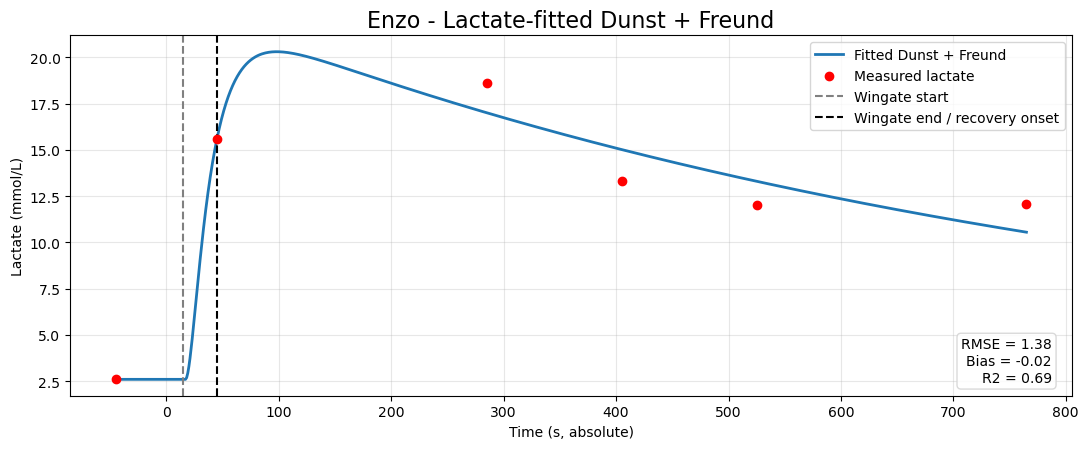

In [31]:
# Enzo-only lactate fit plot with error metrics
enzo_name = "Enzo"

if "fit_df" not in globals() or "fit_curves" not in globals() or "fit_points" not in globals():
    print("Please run the previous fitting cells first.")
else:
    fit_row_enzo = fit_df[fit_df["Participant"].astype(str).str.strip().str.lower() == enzo_name.lower()]

    if fit_row_enzo.empty or enzo_name not in fit_curves or enzo_name not in fit_points:
        print("Enzo is not available in fitted results (check if baseline and handoff points exist).")
    else:
        curve_enzo = fit_curves[enzo_name].copy()
        pts_enzo = fit_points[enzo_name].copy()

        # Exclude baseline from error metrics to match pooled convention used above.
        eval_enzo = pts_enzo.dropna(subset=["La_fit", "[La]", "Time"]).copy()
        eval_enzo = eval_enzo[eval_enzo["Time"] != -1].copy()

        if len(eval_enzo) > 0:
            rmse_enzo = rmse(eval_enzo["[La]"], eval_enzo["La_fit"])
            bias_enzo = bias(eval_enzo["[La]"], eval_enzo["La_fit"])
            r2_enzo = r2_score_safe(eval_enzo["[La]"], eval_enzo["La_fit"])
            r2_str_enzo = f"{r2_enzo:.2f}" if np.isfinite(r2_enzo) else "nan"
            metrics_text = (
                f"RMSE = {rmse_enzo:.2f}\n"
                f"Bias = {bias_enzo:.2f}\n"
                f"R2 = {r2_str_enzo}"
            )
        else:
            metrics_text = "RMSE = nan\nBias = nan\nR2 = nan"

        plt.figure(figsize=(11, 4.6))
        plt.plot(curve_enzo["Time_abs_s"], curve_enzo["La_fit"], label="Fitted Dunst + Freund", color="tab:blue", linewidth=2)
        plt.scatter(pts_enzo["t_abs_s"], pts_enzo["[La]"], color="red", label="Measured lactate", zorder=3)

        plt.axvline(START_TIME_S, linestyle="--", color="gray", label="Wingate start")
        plt.axvline(END_TIME_S, linestyle="--", color="black", label="Wingate end / recovery onset")

        plt.xlabel("Time (s, absolute)")
        plt.ylabel("Lactate (mmol/L)")
        plt.title("Enzo - Lactate-fitted Dunst + Freund", fontsize=16)
        plt.grid(True, alpha=0.3)

        plt.text(
            0.98,
            0.03,
            metrics_text,
            transform=plt.gca().transAxes,
            ha="right",
            va="bottom",
            fontsize=10,
            linespacing=1.25,
            bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
        )

        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()